# HNW & SWE Validation — dSnow (R / nixmass)

Reads the NetCDF produced by `run_dsnow_validation.R` and plots the combined
HNW + SWE validation using `HNW_validation_helper.validate_hnw_swe_combined`.

**Workflow**
1. Run `run_dsnow_validation.R` (edit parameters there, re-run).
2. Open this notebook and run all cells.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path

# ── Project root ──────────────────────────────────────────────────────────────
base_dir = Path("/Users/jakobwerkgarner/code/mt_dsnow")
os.chdir(base_dir)

# ── Paths ─────────────────────────────────────────────────────────────────────
nc_file  = base_dir / "HNW_validation/validation_data/Mag25_dsnow_validation_default_rho_max_dyn.nc"
save_dir = base_dir / "HNW_validation/figures_R_validation/dyn_rho_max_default"

# ── Imports ───────────────────────────────────────────────────────────────────
import HNW_validation.HNW_validation_helper as val_helper
from plot_style import apply_style, C
apply_style()

# ── Run configuration ─────────────────────────────────────────────────────────
calib_comment = "R_default_dyn_rho_max"   # used in saved figure filename
save_fig      = True
cmap          = val_helper.make_model_cmap(C.DSNOW)

In [2]:
# ── Load validation NetCDF ────────────────────────────────────────────────────
ds = xr.open_dataset(nc_file)

# R writes fixed-length byte strings (|S17); decode to plain str.
if ds["station"].dtype.kind == "S":
    station_names = [v.decode("utf-8").strip() for v in ds["station"].values]
    ds = ds.assign_coords(station=station_names)

# Print embedded parameter string for reference
print("Parameters used in R:")
print(ds.attrs.get("dsnow_parameters", "<not found>"))
print(f"dyn_rho_max : {ds.attrs.get('dyn_rho_max', '?')}")
print(ds)

Parameters used in R:
sigma=0.03; mu=80; rho_h=600; rho_l=380; rho.null=80.7371; c.ov=0.000517096; k.ov=0.378231; k=0.029297; tau=0.0235652; eta.null=8.5435e+06; timestep=24
dyn_rho_max : 1
<xarray.Dataset> Size: 3MB
Dimensions:       (station: 41, time: 2191)
Coordinates:
  * time          (time) datetime64[ns] 18kB 2016-09-01T06:00:00 ... 2022-08-...
Dimensions without coordinates: station
Data variables:
    station_name  (station) |S17 697B ...
    SWE_mod       (time, station) float64 719kB ...
    HNW_mod       (time, station) float64 719kB ...
    SWE_obs       (time, station) float64 719kB ...
    HNW_obs       (time, station) float64 719kB ...
Attributes:
    dsnow_parameters:  sigma=0.03; mu=80; rho_h=600; rho_l=380; rho.null=80.7...
    dyn_rho_max:       1
    source:            nixmass::swe.delta.snow


In [3]:
# ── Build long-format DataFrames (mirrors HNW_validation_dSnow.ipynb) ─────────
all_df = (
    ds[["HNW_mod", "SWE_mod", "HNW_obs", "SWE_obs"]]
    .to_dataframe()
    .reset_index()
)

# SWE_val: rows where observed SWE is available (biweekly snow-course data)
SWE_val = all_df[all_df["SWE_obs"].notna()].copy()

# HNW_val: rows where observed HNW is available
HNW_val = all_df[all_df["HNW_obs"].notna()].copy()
HNW_val.index = pd.to_datetime(HNW_val["time"]).values

print(f"Rows total      : {len(all_df):>7}")
print(f"Rows w/ SWE_obs : {len(SWE_val):>7}")
print(f"Rows w/ HNW_obs : {len(HNW_val):>7}")

Rows total      :   89831
Rows w/ SWE_obs :    1157
Rows w/ HNW_obs :   36487


In [4]:
# ── Parameters to display in the plot footer ──────────────────────────────────
# Parsed from the NC global attribute written by the R script.
param_str = ds.attrs.get("dsnow_parameters", "")
params_display = {}
for part in param_str.split(";"):
    part = part.strip()
    if "=" in part:
        k, v = part.split("=", 1)
        try:
            params_display[k.strip()] = float(v.strip())
        except ValueError:
            pass

print("params_display:", params_display)

params_display: {'sigma': 0.03, 'mu': 80.0, 'rho_h': 600.0, 'rho_l': 380.0, 'rho.null': 80.7371, 'c.ov': 0.000517096, 'k.ov': 0.378231, 'k': 0.029297, 'tau': 0.0235652, 'eta.null': 8543500.0, 'timestep': 24.0}


HNW stats: {'RMSE': np.float64(2.96514489310015), 'Bias': np.float64(-0.3416750217171408), 'Rel_BIAS': np.float64(-0.16694316053514888), 'R2': np.float64(0.8283121939404666), 'N': 35409}
SWE stats: {'RMSE': np.float64(36.15880337609435), 'Bias': np.float64(4.715675744358653), 'Rel_BIAS': np.float64(0.02372806363174342), 'R2': np.float64(0.9119463589442891), 'N': 1054}
Plot saved to: /Users/jakobwerkgarner/code/mt_dsnow/HNW_validation/figures_R_validation/dyn_rho_max_default/dSnow_combined_validation_R_default_dyn_rho_max.png


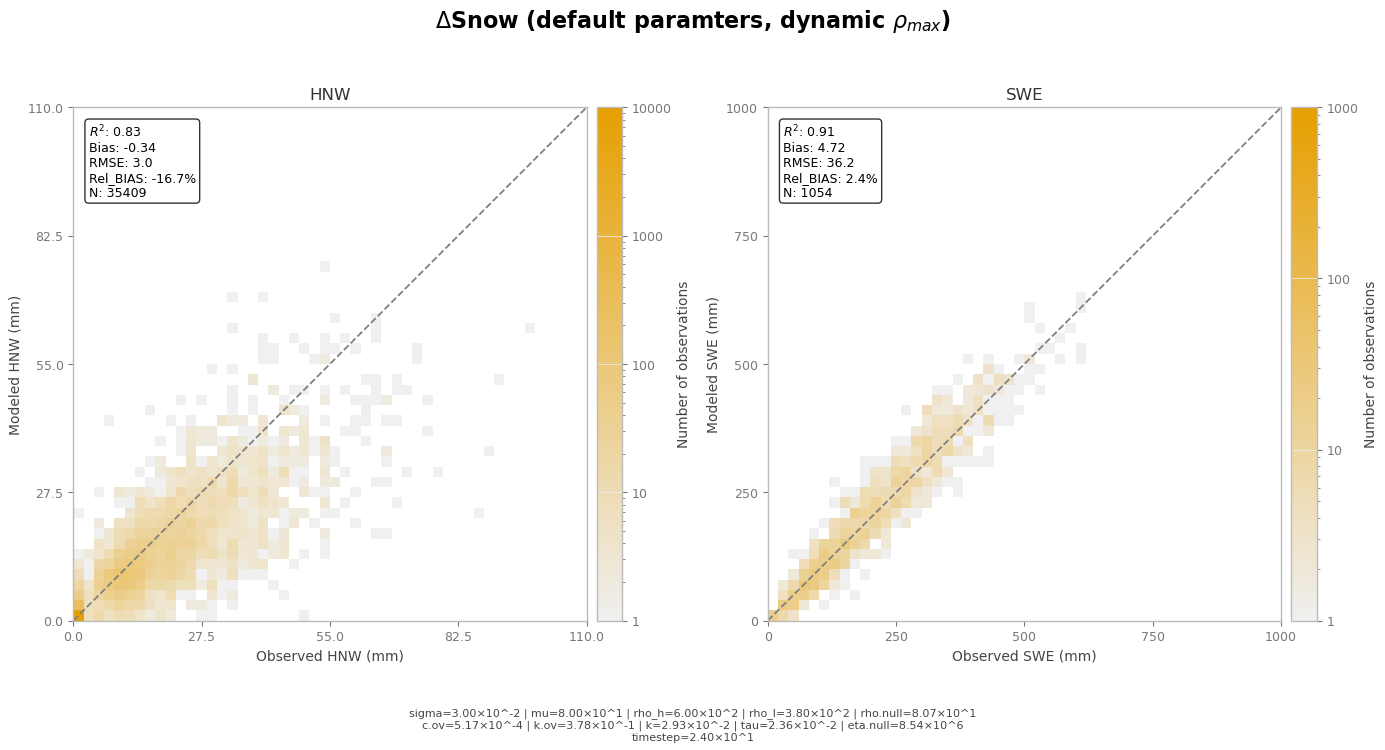

{'HNW': {'RMSE': np.float64(2.96514489310015), 'Bias': np.float64(-0.3416750217171408), 'Rel_BIAS': np.float64(-0.16694316053514888), 'R2': np.float64(0.8283121939404666), 'N': 35409}, 'SWE': {'RMSE': np.float64(36.15880337609435), 'Bias': np.float64(4.715675744358653), 'Rel_BIAS': np.float64(0.02372806363174342), 'R2': np.float64(0.9119463589442891), 'N': 1054}}


In [5]:
# ── Combined HNW + SWE validation plot ───────────────────────────────────────
results = val_helper.validate_hnw_swe_combined(
    hnw_df     = HNW_val,
    swe_df     = SWE_val,
    model_name = r"$\Delta$Snow (default paramters, dynamic $\rho_{max}$)",
    params     = params_display,
    full_season= False,
    save_dir   = save_dir if save_fig else None,
    filename   = f"dSnow_combined_validation_{calib_comment}.png",
    cmap       = cmap,
)

print(results)